# Projekt 3

## Filip Nocoń
---

### Inicjalizacja potrzebnych bibliotek

In [1]:
# Tutaj należy zaimport pandas as pdimportować potrzebne biblioteki.:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr

import numpy as np
%matplotlib inline

----
### 1. Wczytanie plików z danymi 

In [2]:
df = pd.read_csv("data_7r.csv")

df.head()

,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,cluster
0,5.861462,-7.082981,9.980654,11.092861,-1.910903,-2.509957,-0.637467,-1.963482,-2.364494,1
1,-0.634395,1.229414,9.502255,-1.420413,-3.222716,-0.542408,-3.400873,3.290485,0.552732,2
2,2.893711,0.115931,7.283339,-3.220003,-0.236667,-0.115186,-7.471631,7.230080,4.880379,0
3,3.469292,-0.897882,5.838554,2.682485,-3.953200,1.932844,-1.556870,1.769251,2.545101,1
4,-0.033693,0.839282,3.004295,8.413292,-0.406135,-3.419393,12.158579,9.249545,5.744299,3


---
### 2. Wykresy rozrzutu wraz z prostą regresji

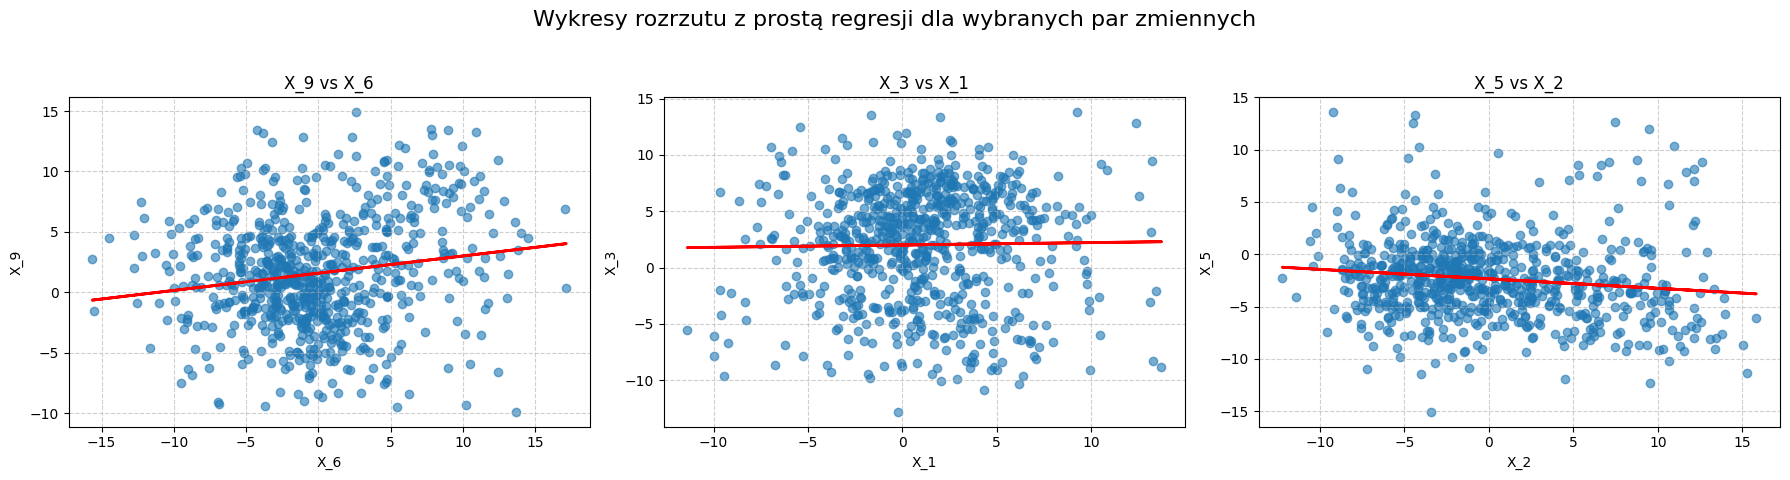

In [3]:
regresja_liniowa = LinearRegression()

pairs = [('X_6', 'X_9'), ('X_1', 'X_3'), ('X_2', 'X_5')] 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Wykresy rozrzutu z prostą regresji dla wybranych par zmiennych', fontsize=16)

Y_pred = []
X_data = []
Y_data = []


for i, (x_col, y_col) in enumerate(pairs):
    
    X_data.append(df[x_col].values.reshape(-1, 1))
    Y_data.append(df[y_col].values)
    
    regresja_liniowa.fit(X_data[i], Y_data[i])
    
    Y_pred.append(regresja_liniowa.predict(X_data[i]))
    
    axes[i].scatter(df[x_col], df[y_col], alpha=0.6)
    axes[i].plot(df[x_col], Y_pred[i], color='red', linewidth=2)
    
    axes[i].set_title(f'{y_col} vs {x_col}')
    
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
### 3. Wyznaczenie współczynnika $R^2$ 

In [4]:
r2 = []

for i in range(0,3):
    r2.append(r2_score(Y_data[i], Y_pred[i])) # im bliżej 1 to lepiej - gdzie 1 to jest perfekcyjne dopasowanie
print(r2)

[0.02734390914715068, 0.0002852403229758327, 0.017616027320401906]


#### <span style="color:blue">Wnioski :</span>

Wyniki świadczą o bardzo słabym dopasowaniu modelu do danych wejściowych.

---
### 4. Błąd średniokwadratowy i wariancja wyjaśniona

In [5]:
# MSE i EVS
MSE = [] # błąd średniokwadradoty
EVS = [] # wariancja wyjaśniona
for i in range(0,3):
    MSE.append(mean_squared_error(Y_data[i], Y_pred[i]))
    EVS.append(explained_variance_score(Y_data[i], Y_pred[i])) # najlepsze jest 1 im niżej tym gorzej
print(MSE)
print(EVS)

[20.436865932367674, 25.34220745439933, 14.569948873255415]
[0.02734390914715057, 0.0002852403229758327, 0.017616027320401906]


---
### 5. Badanie istotności zależności liniowej

In [6]:
#H_0: Nie ma zależności liniowej
flat_x = []
flat_y = []
for i in range(0,3):
    flat_x.append(np.squeeze(X_data[i])) # korelacja od -1 do 1
    flat_y.append(np.squeeze(Y_data[i])) # p.v > 0.05 - nie ma podstaw do odrzucenia h_0
    print(pearsonr(flat_x[i],flat_y[i]))


PearsonRResult(statistic=np.float64(0.16535993815658823), pvalue=np.float64(5.7022382320445344e-06))
PearsonRResult(statistic=np.float64(0.016889059268531077), pvalue=np.float64(0.6453436936498226))
PearsonRResult(statistic=np.float64(-0.13272538310512394), pvalue=np.float64(0.00028047309591244866))


#### <span style="color:blue">Wnioski :</span>
Wykres 1:
    p.v > 0.05, czyli odrzucamy - Czyli istnieje jakaś zależność jednak jest ona raczej mała.
Wykres 2:
    p.v < 0.05, H_0 zostaje
Wykres 3:
    p.v > 0.05, czyli odrzucamy - Czyli istnieje jakaś zależność jednak jest ona raczej mała.

---
### 6. Zadanie dodatkowe (dla chętnych)

#### <span style="color:blue">Wnioski :</span>

#### <span style="color:blue">Dokumentacja :</span>

- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.explained_variance_score.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html


###

In [7]:
# Eksportowanie bieżacego notatnika do pdf.

%run ../data/notebook_export
export_notebook_to_pdf("Projekt3_Nocoń_Filip.ipynb")

Export 'Projekt3_Nocoń_Filip.ipynb': OK.


<Figure size 640x480 with 0 Axes>

**PDF wygenerowano:** Wednesday, 26 November 2025 16:08:54

**PDF wygenerowano:** Wednesday, 26 November 2025 16:10:03